# 12 — Aethalometer

**Theme:** wavelength-resolved black carbon, and what the extra wavelengths buy
you.

An aethalometer draws air through a filter and measures how much light the
collected particles absorb. Absorption is converted to a **black-carbon
equivalent mass concentration** — the mass of pure soot that would have absorbed
that much.

In [1]:
import matplotlib.pyplot as plt

import aerosoltools as at

aeth = at.load_aethalometer_file("../../tests/data/Sample_Aethalometer.csv")

print("instrument:", aeth.instrument)
print("columns   :", list(aeth.data))

instrument: Aethalometer
columns   : ['IR BCc', 'UV BCc', 'Blue BCc', 'Green BCc', 'Red BCc', 'Biomass BCc', 'Fossil fuel BCc', 'AAE', 'All data']


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Why there is a BC value per wavelength

There is no single "BC" channel. The instrument measures attenuation
independently at each of its five wavelengths, and converts **each** to its own
BC-equivalent mass using a mass absorption cross-section for that wavelength.
The raw export makes the chain visible: per colour it carries `ATN1`/`ATN2`
(attenuation on two filter spots), `BC1`/`BC2` (the mass from each spot) and
`BCc` — the loading-corrected value combining them, which is what is loaded
here.

So all five are BC estimates of the same air, and if only soot were present
they would agree. They do not, and that disagreement is the useful part: soot
absorbs across the whole spectrum roughly evenly, while brown carbon from wood
smoke and organics absorbs far more strongly in the ultraviolet. UV therefore
reads high whenever something other than pure soot is present.

By convention **IR is reported as "the" black carbon**, because it is the
channel least contaminated by those other absorbers.

In [2]:
for name in ["uv_bcc", "blue_bcc", "green_bcc", "red_bcc", "ir_bcc"]:
    channel = getattr(aeth, name)
    print(f"{name:10s} mean {channel.mean():9.1f}  max {channel.max():9.1f}")

print()
print(f"UV / IR ratio: {aeth.uv_bcc.mean() / aeth.ir_bcc.mean():.3f}")

uv_bcc     mean    2781.8  max   31895.0
blue_bcc   mean    2850.0  max   32115.0
green_bcc  mean    2736.6  max   31068.0
red_bcc    mean    2726.7  max   30463.0
ir_bcc     mean    2692.8  max   30476.0

UV / IR ratio: 1.033


A ratio above 1 means the UV channel sees absorption the IR channel does not —
the signature of non-soot absorbers.

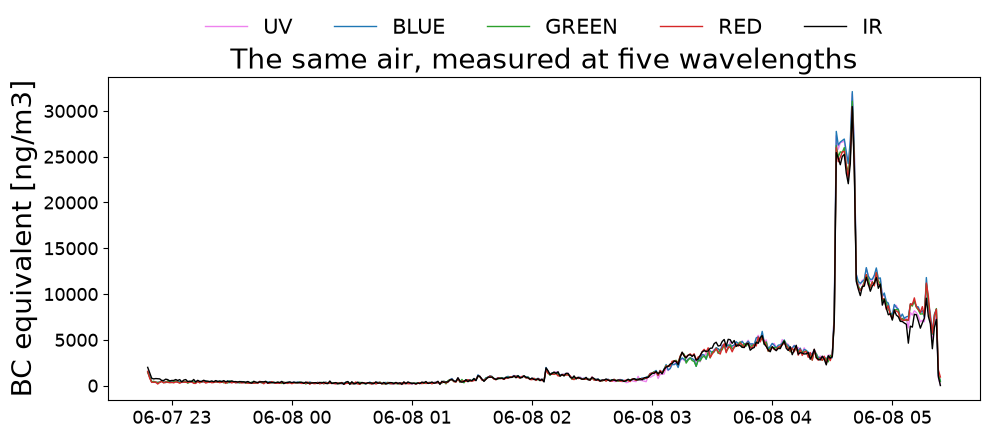

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for name, colour in [("uv_bcc", "violet"), ("blue_bcc", "tab:blue"),
                     ("green_bcc", "tab:green"), ("red_bcc", "tab:red"),
                     ("ir_bcc", "black")]:
    ax.plot(aeth.time, getattr(aeth, name),
            label=name.replace("_bcc", "").upper(), color=colour, lw=1)

ax.set_ylabel("BC equivalent [ng/m3]")
ax.set_title("The same air, measured at five wavelengths")
ax.legend(ncol=5, loc="lower center", bbox_to_anchor=(0.5, 1.06), frameon=False)
plt.tight_layout()

## Per-channel units

The channels are not all the same quantity, so each carries its own unit and
dtype — the mass concentrations in ng/m³, the Ångström exponent dimensionless.

In [4]:
aeth.column_units

{'GPS speed': 'km/h',
 'Timebase': 's',
 'Battery remaining': '%',
 'Flow setpoint': 'l/min',
 'Flow total': 'l/min',
 'Flow1': 'l/min',
 'Flow2': 'l/min',
 'Sample temp': '°C',
 'Sample RH': '%',
 'Sample dewpoint': '°C',
 'Internal pressure': 'hPa',
 'Internal temp': '°C',
 'UV BC1 smoothed': 'µg/m³',
 'UV BCc smoothed': 'µg/m³',
 'Blue BC1 smoothed': 'µg/m³',
 'Blue BCc smoothed': 'µg/m³',
 'IR BC1 smoothed': 'µg/m³',
 'IR BCc smoothed': 'µg/m³',
 'BB': '%',
 'Delta-C': 'µg/m³',
 'Reporting Temp': '°C',
 'Reporting Pressure': 'hPa'}

## The Angstrom absorption exponent

The AAE condenses the spectral shape into one number: how steeply absorption
falls off with wavelength. Values near 1 indicate fresh fossil-fuel soot; higher
values indicate wood smoke or other organic-rich aerosol.

In [5]:
print(f"AAE mean   : {aeth.aae.mean():.3f}")
print(f"AAE median : {aeth.aae.median():.3f}")
print(f"AAE range  : {aeth.aae.min():.3f} to {aeth.aae.max():.3f}")

AAE mean   : 0.990
AAE median : 1.040
AAE range  : 0.130 to 1.430


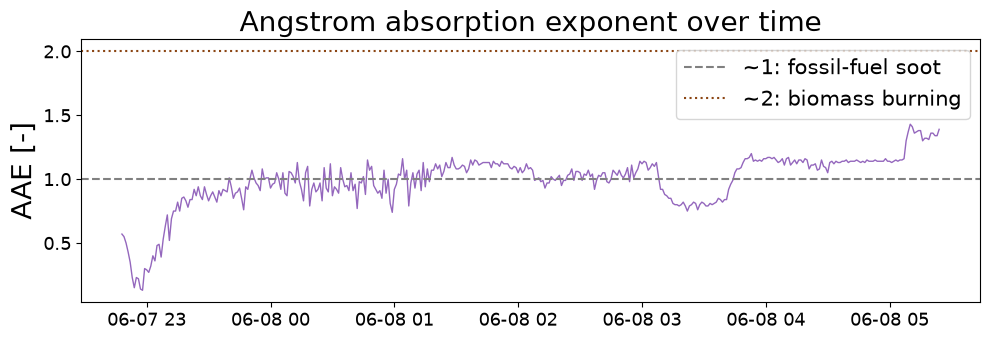

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(aeth.time, aeth.aae, color="tab:purple", lw=1)
ax.axhline(1.0, ls="--", color="gray", label="~1: fossil-fuel soot")
ax.axhline(2.0, ls=":", color="saddlebrown", label="~2: biomass burning")
ax.set_ylabel("AAE [-]")
ax.legend(loc="upper right")
ax.set_title("Angstrom absorption exponent over time")
plt.tight_layout()

## Source apportionment

Because soot and wood smoke have different spectral slopes, the measured AAE
can be used to split the signal into a fossil-fuel and a biomass-burning
contribution. The instrument reports both directly.

In [7]:
print(f"fossil fuel : {aeth.fossil_bcc.mean():9.1f} ng/m3")
print(f"biomass     : {aeth.biomass_bcc.mean():9.1f} ng/m3")
print(f"IR total    : {aeth.ir_bcc.mean():9.1f} ng/m3")

fossil fuel :    2458.0 ng/m3
biomass     :     266.1 ng/m3
IR total    :    2692.8 ng/m3


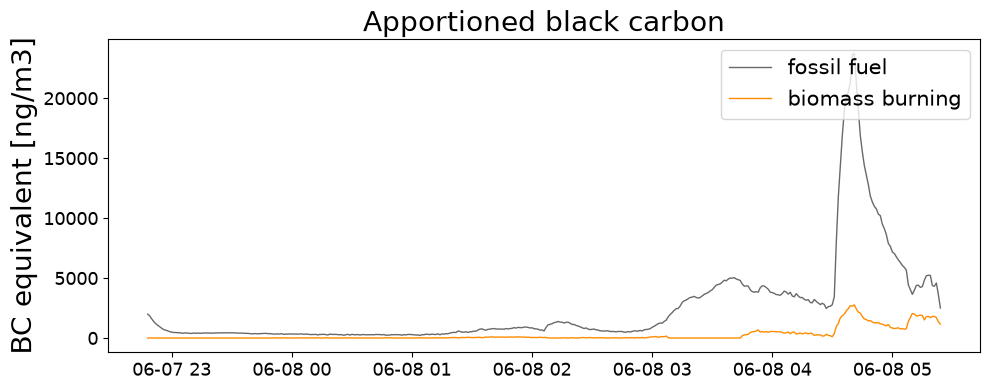

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(aeth.time, aeth.fossil_bcc, label="fossil fuel", color="dimgray", lw=1)
ax.plot(aeth.time, aeth.biomass_bcc, label="biomass burning", color="darkorange", lw=1)
ax.set_ylabel("BC equivalent [ng/m3]")
ax.legend(loc="upper right")
ax.set_title("Apportioned black carbon")
plt.tight_layout()

The apportionment inherits the assumptions behind it — fixed Ångström exponents
for the two source types — so treat it as an indication of the mix rather than a
measured quantity.

## Everything else still applies

An `Aethalometer` is an ordinary time series, so activities, cropping and
summaries work as usual. Because the channels are separate columns rather than a
size distribution, summaries are per channel.

In [9]:
midpoint = len(aeth.time) // 2
aeth.mark_activities({
    "First half":  [(str(aeth.time[0]), str(aeth.time[midpoint]))],
    "Second half": [(str(aeth.time[midpoint + 1]), str(aeth.time[-1]))],
})
aeth.summarize_activities()


Summary of aerosol metrics per activity:

+---------------------+----------+------------+-------------+
|                     | All data | First half | Second half |
+---------------------+----------+------------+-------------+
|  Duration (HH:MM)   |  06:37   |   03:19    |    03:18    |
| IR BCc [ng/m³] mean | 2692.791 |  481.422   |  4917.318   |
| IR BCc [ng/m³] std  | 4439.713 |  249.864   |  5443.902   |
+---------------------+----------+------------+-------------+


,Segment,Duration (HH:MM),IR BCc [ng/m³] mean,IR BCc [ng/m³] std
0,All data,06:37,2692.791,4439.713
1,First half,03:19,481.422,249.864
2,Second half,03:18,4917.318,5443.902


---

**Next:** [13 — APS](13-aps.ipynb).